> Tensorflow Documentation - https://www.tensorflow.org/api_docs/python/

UV is An extremely fast Python package and project manager, faster 10-100x time than pip.
Installing UV, setting Up Virtual Environment and downloading depending dependencies.

```sh
pip install uv
uv venv
uv pip install -r requirements.txt
```

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd

# Common Tensorflow Methods

This notebook focuses particularly on common tensorflow methods used.

In [2]:
# expand_dims - Returns a tensor with a length 1 axis inserted at index axis.

tensor_three_d = tf.constant([
    [ [1,2,0], [3,5,-1] ],
    [ [10,2,0], [1,0,2] ],
    [ [5,8,0], [2,7,0] ],
    [ [2,1,9], [4,13,32] ]
])

tensor_three_d.shape

TensorShape([4, 2, 3])

In [3]:
print(tf.expand_dims( tensor_three_d, axis = 0).shape) # 1,4,2,3

(1, 4, 2, 3)


In [4]:
tf.expand_dims( tensor_three_d, axis = 0)

<tf.Tensor: shape=(1, 4, 2, 3), dtype=int32, numpy=
array([[[[ 1,  2,  0],
         [ 3,  5, -1]],

        [[10,  2,  0],
         [ 1,  0,  2]],

        [[ 5,  8,  0],
         [ 2,  7,  0]],

        [[ 2,  1,  9],
         [ 4, 13, 32]]]], dtype=int32)>

In [5]:
# Conversion of 1-D Tensor to 2-D
x = tf.constant([2,3,4,5])
print(x.shape)
print(tf.expand_dims(x, axis = 0).shape)

(4,)
(1, 4)


In [6]:
print(tf.expand_dims( tensor_three_d, axis = 1).shape) # 4,1,2,3
print(tf.expand_dims( tensor_three_d, axis = 3 ).shape) # 4,2,3,1
print(tf.expand_dims( tensor_three_d, axis = -1 ).shape) # Same result as 3

(4, 1, 2, 3)
(4, 2, 3, 1)
(4, 2, 3, 1)


In [7]:
# squeeze - Removes dimensions of size 1 from the shape of a tensor.
x = tf.constant([[[[2,3,4,5]]]])
print(x.shape)
tf.squeeze(x, axis = 0)

(1, 1, 1, 4)


<tf.Tensor: shape=(1, 1, 4), dtype=int32, numpy=array([[[2, 3, 4, 5]]], dtype=int32)>

In [8]:
tf.squeeze(x, [1,2]) # Squeezed dimensions at index 1 & 2

<tf.Tensor: shape=(1, 4), dtype=int32, numpy=array([[2, 3, 4, 5]], dtype=int32)>

In [9]:
tf.squeeze(x) # Squeeze all dimensions suitable

<tf.Tensor: shape=(4,), dtype=int32, numpy=array([2, 3, 4, 5], dtype=int32)>

In [10]:
# reshape - Reshapes a tensor.

t1 = [[1, 2, 3],
      [4, 5, 6]]

t2 = tf.reshape(t1, [6]) # same for -1
print(t2)

tf.reshape(t2, [3, 2])

tf.Tensor([1 2 3 4 5 6], shape=(6,), dtype=int32)


<tf.Tensor: shape=(3, 2), dtype=int32, numpy=
array([[1, 2],
       [3, 4],
       [5, 6]], dtype=int32)>

In [11]:
# concat - Concatenates tensors along one dimension.

t1 = [[1, 2, 3], [4, 5, 6]]
t2 = [[7, 8, 9], [10, 11, 12]]
print(tf.concat([t1, t2], 0)) # Row concatenation
print(tf.concat([t1, t2], 1)) # Column concatenation

# using stack for alternate "tf.concat([tf.expand_dims(t, axis) for t in tensors], axis)"

print(tf.stack([t1, t2], 0)) # Using Stack to concatenate on new dimension
print(tf.stack([t1, t2], 2)) # Using Stack to concatenate on new dimension

tf.Tensor(
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8  9]
 [10 11 12]], shape=(4, 3), dtype=int32)
tf.Tensor(
[[ 1  2  3  7  8  9]
 [ 4  5  6 10 11 12]], shape=(2, 6), dtype=int32)
tf.Tensor(
[[[ 1  2  3]
  [ 4  5  6]]

 [[ 7  8  9]
  [10 11 12]]], shape=(2, 2, 3), dtype=int32)
tf.Tensor(
[[[ 1  7]
  [ 2  8]
  [ 3  9]]

 [[ 4 10]
  [ 5 11]
  [ 6 12]]], shape=(2, 3, 2), dtype=int32)


In [12]:
# pad - Pads a tensor.

t = tf.constant([[1, 2, 3], [4, 5, 6]])
print(t)
paddings = tf.constant([[1, 1,], [2, 2]]) # 1 row at top & bottom, 2 column at left & right
# 'constant_values' is 0.
# rank of 't' is 2.
print(tf.pad(t, paddings, "CONSTANT"))  # [[0, 0, 0, 0, 0, 0, 0],
                                        #  [0, 0, 1, 2, 3, 0, 0],
                                        #  [0, 0, 4, 5, 6, 0, 0],
                                        #  [0, 0, 0, 0, 0, 0, 0]]

print(tf.pad(t, paddings, "REFLECT"))   # [[6, 5, 4, 5, 6, 5, 4],
                                        #  [3, 2, 1, 2, 3, 2, 1],
                                        #  [6, 5, 4, 5, 6, 5, 4],
                                        #  [3, 2, 1, 2, 3, 2, 1]]

print(tf.pad(t, paddings, "SYMMETRIC")) # [[2, 1, 1, 2, 3, 3, 2],
                                        #  [2, 1, 1, 2, 3, 3, 2],
                                        #  [5, 4, 4, 5, 6, 6, 5],
                                        #  [5, 4, 4, 5, 6, 6, 5]]

tf.Tensor(
[[1 2 3]
 [4 5 6]], shape=(2, 3), dtype=int32)
tf.Tensor(
[[0 0 0 0 0 0 0]
 [0 0 1 2 3 0 0]
 [0 0 4 5 6 0 0]
 [0 0 0 0 0 0 0]], shape=(4, 7), dtype=int32)
tf.Tensor(
[[6 5 4 5 6 5 4]
 [3 2 1 2 3 2 1]
 [6 5 4 5 6 5 4]
 [3 2 1 2 3 2 1]], shape=(4, 7), dtype=int32)
tf.Tensor(
[[2 1 1 2 3 3 2]
 [2 1 1 2 3 3 2]
 [5 4 4 5 6 6 5]
 [5 4 4 5 6 6 5]], shape=(4, 7), dtype=int32)


In [13]:
# gather - Gather slices from params axis axis according to indices. (deprecated arguments)

params = tf.constant(['p0', 'p1', 'p2', 'p3', 'p4', 'p5'])
params[3].numpy()

tf.gather(params, 3).numpy()

b'p3'

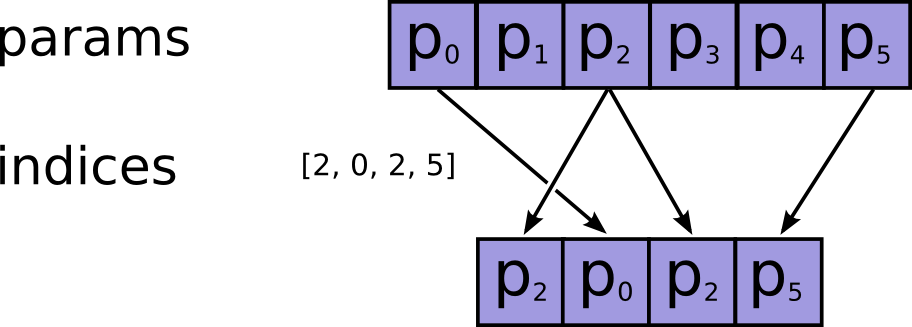

In [14]:
indices = [2, 0, 2, 5]
tf.gather(params, indices).numpy()

array([b'p2', b'p0', b'p2', b'p5'], dtype=object)

In [15]:
params = tf.constant([[0, 1.0, 2.0],
                      [10.0, 11.0, 12.0],
                      [20.0, 21.0, 22.0],
                      [30.0, 31.0, 32.0]])
tf.gather(params, indices=[3,1]).numpy()

array([[30., 31., 32.],
       [10., 11., 12.]], dtype=float32)

In [16]:
tf.gather(params, indices=[2,1], axis=1).numpy()

array([[ 2.,  1.],
       [12., 11.],
       [22., 21.],
       [32., 31.]], dtype=float32)

In [17]:
# gather_nd - Gather slices from params into a Tensor with shape specified by indices.

tf.gather_nd(
    indices=[[0, 0],[1, 1]],
    params = [['a', 'b'],['c', 'd']]
).numpy()

array([b'a', b'd'], dtype=object)

In [18]:
tf.gather_nd(
    indices = [[1],[0]],
    params = [['a', 'b', 'c'], ['d', 'e', 'f']]
).numpy()


array([[b'd', b'e', b'f'],
       [b'a', b'b', b'c']], dtype=object)

In [19]:
tf.gather_nd(
    indices = [[0, 1],[1, 0]],
    params= [
        [ ['ao', 'b0'],['c0', 'd0'] ], # batch at index 0, from which array at index 1 -> ['c0', 'd0']
        [ ['a1', 'b1'],['c1', 'd1'] ]  # batch at index 1, from which array at index 0 -> ['a1', 'b1']
    ],
    batch_dims=0 # default - 0
)

<tf.Tensor: shape=(2, 2), dtype=string, numpy=
array([[b'c0', b'd0'],
       [b'a1', b'b1']], dtype=object)>

In [20]:
tf.gather_nd(
    indices = [[0, 1],[1, 0]],
    params= [
        [ ['ao', 'b0'],['c0', 'd0'] ], # batch 1 - [0,1] index -> b0
        [ ['a1', 'b1'],['c1', 'd1'] ] # batch 2 - [1,0] index -> c1
    ],
    batch_dims=1
)

<tf.Tensor: shape=(2,), dtype=string, numpy=array([b'b0', b'c1'], dtype=object)>